# SIM (UNIT) → FastPM Haloscope enrichment

Schema notebook (not executed in CI). Wires **UNIT** consistent-trees and **FastPM** Rockstar `out_8.list` at **scale factor a=1 (z=0)** through Haloscope (`density_field_properties.haloscope`).

**Inputs:** `config/fastpm_folders.md`, paths in `haloscope/sim_to_fastpm/config.py`.

**Outputs:** enriched Parquet under `output/sim_to_fastpm_haloscope/`, validation PDFs.

Relation to `density_field_properties`: same Rockstar `.list` as tidal pipelines; here `env` is a halo-halo KD-tree proxy, not the tidal tensor from the density field.

## 0. Python path

Run from repo root or set `REPO_ROOT` below. Requires `src` on `PYTHONPATH`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src" / "density_field_properties").is_dir():
    REPO_ROOT = Path.cwd().parent

sys.path.insert(0, str(REPO_ROOT / "src"))

from density_field_properties.haloscope import ConditionalMultiVariateGaussian

## 1. Configuration

| Quantity | Value |
|----------|--------|
| UNIT SIM | `/data5/UNITSIM/fixedAmp_InvPhase_001/ROCKSTAR/outputs` → `hlists/hlist_1.00000.list.bz2` |
| FastPM | `/data21/users/mruiz/fastpm_MN5/fastpm_tfm/rockstar_out_pm/out_8.list` |
| Box (both) | 1000 Mpc/h (UNIT header + `default_params.L_BOX`) |
| Cosmology | Om=0.3089, Ol=0.6911, h=0.6774 in both catalogs |

Set `QUICK_RUN = True` in the config cell for subset limits (`SMOKE_*`); `False` uses `MAX_*_HALOS` (`None` = full catalogs).

In [2]:
from density_field_properties.haloscope.sim_to_fastpm import config
from density_field_properties.haloscope.sim_to_fastpm.config import (
    ENV_RADIUS_MPC_H,
    OUTPUT_DIR,
    ENRICHED_PARQUET_NAME,
    QUICK_RUN,
    default_fastpm_list_path,
    max_fastpm_halos_for_run,
    max_sim_halos_for_run,
    min_bin_size_for_run,
    default_sim_hlist_path,
)

config.QUICK_RUN = True  # subset run (SMOKE_* limits in config.py)
CALIBRATE_MASS = False

MAX_SIM_HALOS = max_sim_halos_for_run(config.QUICK_RUN)
MAX_FASTPM_HALOS = max_fastpm_halos_for_run(config.QUICK_RUN)
MIN_BIN_SIZE = min_bin_size_for_run(config.QUICK_RUN)

SIM_PATH = default_sim_hlist_path()
FASTPM_PATH = default_fastpm_list_path()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"QUICK_RUN={config.QUICK_RUN}  MAX_SIM={MAX_SIM_HALOS}  MAX_FASTPM={MAX_FASTPM_HALOS}")

QUICK_RUN=True  MAX_SIM=8000  MAX_FASTPM=8000


## 2. Load catalogs

In [3]:
from density_field_properties.haloscope.sim_to_fastpm.load_catalogs import (
    load_fastpm_target_catalog,
    load_unit_sim_training_catalog,
)

halos_sim = load_unit_sim_training_catalog(SIM_PATH, max_halos=MAX_SIM_HALOS)
halos_fastpm = load_fastpm_target_catalog(FASTPM_PATH, max_halos=MAX_FASTPM_HALOS)
print(f"UNIT hosts: {len(halos_sim)}")
print(f"FastPM halos: {len(halos_fastpm)}")

UNIT hosts: 7162
FastPM halos: 1981597


(array([1.19599881e-13, 8.10118143e-14, 4.58844485e-14, ...,
        0.00000000e+00, 0.00000000e+00, 2.05920532e-19], shape=(1407,)),
 array([1.80590000e+12, 4.25657100e+12, 6.70724200e+12, ...,
        3.44499866e+15, 3.44744933e+15, 3.44990000e+15], shape=(1408,)),
 <BarContainer object of 1407 artists>)

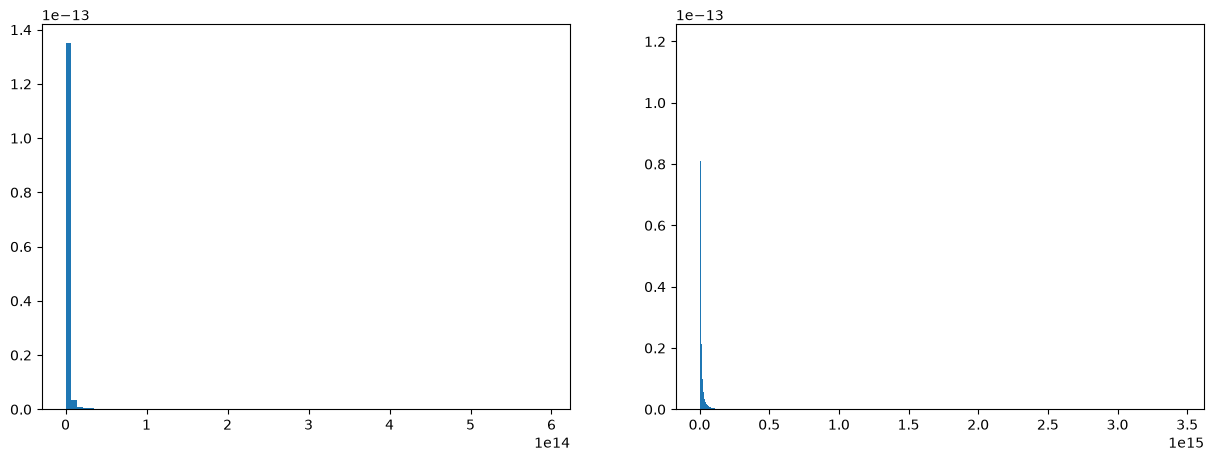

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(15,5))

axes[0].hist(halos_sim.M200b, density=True,bins=int(np.sqrt(len(halos_sim))))
axes[1].hist(halos_fastpm.M200b, density=True, bins=int(np.sqrt(len(halos_fastpm))))


## 3. Optional mass calibration (FastPM → SIM mass function)

In [5]:
from density_field_properties.haloscope.sim_to_fastpm.mass_matching import abundance_match_mass

if CALIBRATE_MASS:
    halos_fastpm["M200b_cal"] = abundance_match_mass(
        halos_fastpm["M200b"].to_numpy(), halos_sim["M200b"].to_numpy()
    )
    MASS_COL_FASTPM = "M200b_cal"
else:
    MASS_COL_FASTPM = "M200b"

## 4. Local environment feature `env` (identical algorithm, each box size)

In [6]:
from density_field_properties.haloscope.sim_to_fastpm.environment import local_environment
from density_field_properties.haloscope.sim_to_fastpm.config import FASTPM_BOXSIZE_MPC_H, SIM_BOXSIZE_MPC_H

halos_sim["env"] = local_environment(
    halos_sim[["x", "y", "z"]].to_numpy(),
    SIM_BOXSIZE_MPC_H,
    radius_mpc_h=ENV_RADIUS_MPC_H,
)
halos_fastpm["env"] = local_environment(
    halos_fastpm[["x", "y", "z"]].to_numpy(),
    FASTPM_BOXSIZE_MPC_H,
    radius_mpc_h=ENV_RADIUS_MPC_H,
)

## 5. Mass bins and SIM hold-out validation

In [7]:
import numpy as np
from density_field_properties.haloscope.sim_to_fastpm.training import default_mass_bin_edges, holdout_validate_sim_bins

BIN_EDGES = default_mass_bin_edges(np.log10(halos_sim["M200b"].max()))
val_results = holdout_validate_sim_bins(halos_sim, BIN_EDGES, min_bin_size=MIN_BIN_SIZE)

here
acceptance rate is  95.27896995708154 %
here
acceptance rate is  95.31568228105907 %
here
acceptance rate is  93.27731092436974 %


/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (444). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (471). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (471). n_quantiles is set to n_samples.
  warnings.warn(
/home/arnes/miniconda3/envs/density_field_properties/lib/python3.14/site-packages/sklearn/preprocessing/_data.py:2905: UserWarning: n_quantiles (500) is greater than the total number of samples (111). n_quantiles is set to n_samples.
  warnings.wa

In [8]:
val_results

[(0, None, None),
 (1,
  array([[16.81795534,  0.03807   ,  0.70646   ,  0.87175   ],
         [ 9.55911075,  0.02523   ,  0.64693   ,  0.78771   ],
         [15.84682414,  0.02751   ,  0.8016    ,  0.98856   ],
         ...,
         [19.06944311,  0.04291   ,  0.59207   ,  0.65393   ],
         [13.92465811,  0.02123   ,  0.70995   ,  0.87152   ],
         [ 7.33540768,  0.03399   ,  0.73838   ,  0.75827   ]],
        shape=(444, 4)),
  array([[ 6.47436414,  0.14609529,  0.67150896,  0.75277129],
         [10.56612856,  0.0417968 ,  0.84617233,  0.96193679],
         [11.89510143,  0.0586932 ,  0.74452733,  0.88262102],
         ...,
         [12.52693216,  0.06203354,  0.84175011,  0.96370859],
         [13.09625201,  0.04943536,  0.69324684,  0.82908582],
         [ 5.94729223,  0.06948784,  0.78925296,  0.82940405]],
        shape=(444, 4))),
 (2,
  array([[1.22390112e+01, 2.47900000e-02, 7.00580000e-01, 9.43860000e-01],
         [1.33345962e+01, 2.39100000e-02, 8.59160000e-01, 9.

## 6. Train on full SIM and enrich FastPM

In [9]:
from density_field_properties.haloscope.sim_to_fastpm.training import enrich_fastpm_catalog

halos_fastpm_enriched, models = enrich_fastpm_catalog(
    halos_sim,
    halos_fastpm,
    BIN_EDGES,
    mass_column_fastpm=MASS_COL_FASTPM,
    min_bin_size=MIN_BIN_SIZE,
)
out_parquet = OUTPUT_DIR / ENRICHED_PARQUET_NAME
halos_fastpm_enriched.to_parquet(out_parquet, index=False)
print("saved:", out_parquet)

here
acceptance rate is  95.0468604591519 %
here
acceptance rate is  95.56069785963035 %
saved: output/sim_to_fastpm_haloscope/fastpm_out_8_haloscope_enriched.parquet


In [10]:
halos_fastpm_enriched

,x,y,z,M200b,id,env,cv,Spin,ca,ba
0,10.03313,12.49149,6.23009,5.637300e+12,0,0.000000,11.417239,0.012472,0.808545,0.906821
1,3.83153,13.84306,14.22381,8.121700e+12,1,0.477121,7.803285,0.041428,0.548382,0.765447
2,5.45069,23.41827,6.11232,2.574200e+12,2,0.301030,8.235471,0.051619,0.757881,0.833539
3,6.87074,22.40835,2.64381,4.769200e+12,3,0.477121,12.106500,0.010526,0.622900,0.799755
4,2.32756,16.39032,15.72766,6.485400e+12,4,0.301030,10.075360,0.017093,0.696128,0.885580
...,...,...,...,...,...,...,...,...,...,...
1981592,930.27332,992.76733,998.51276,5.347900e+13,1981592,0.301030,11.091811,0.013909,0.826320,0.860914
1981593,998.75824,899.04706,939.82990,3.254700e+13,1981593,0.477121,4.597311,0.045184,0.623421,0.682094
1981594,999.26385,913.49860,925.49255,4.310300e+12,1981594,0.000000,8.361528,0.028554,0.598553,0.664716
1981595,992.57703,879.19043,980.81116,2.324800e+12,1981595,0.000000,8.087329,0.028465,0.755948,0.878224


## 7. Diagnostics (corner plots + M–property medians)

In [11]:
import pandas as pd
from density_field_properties.haloscope.sim_to_fastpm.config import OUTPUT_FEATURES
from density_field_properties.haloscope.sim_to_fastpm.plotting import corner_plot_sim_validation, median_property_vs_mass
import matplotlib.pyplot as plt

for bin_index, y_true, y_pred in val_results:
    if y_true is None:
        continue
    df_true = pd.DataFrame(y_true, columns=OUTPUT_FEATURES)
    corner_plot_sim_validation(
        df_true,
        y_pred,
        f"SIM hold-out — mass bin {bin_index}",
        str(OUTPUT_DIR / f"val_sim_bin{bin_index}.pdf"),
    )

In [12]:
logM_fastpm = np.log10(halos_fastpm_enriched[MASS_COL_FASTPM].to_numpy())
for bin_index in range(len(BIN_EDGES) - 1):
    lo, hi = BIN_EDGES[bin_index], BIN_EDGES[bin_index + 1]
    sim_bin = halos_sim[(np.log10(halos_sim.M200b) >= lo) & (np.log10(halos_sim.M200b) < hi)]
    fp_mask = (logM_fastpm >= lo) & (logM_fastpm < hi)
    fp_bin = halos_fastpm_enriched.loc[fp_mask & halos_fastpm_enriched["cv"].notna()]
    if len(sim_bin) < 10 or len(fp_bin) < 10:
        continue
    corner_plot_sim_validation(
        sim_bin,
        fp_bin[list(OUTPUT_FEATURES)].to_numpy(),
        f"SIM vs FastPM generated — mass bin {bin_index}",
        str(OUTPUT_DIR / f"sim_vs_fastpm_bin{bin_index}.pdf"),
    )

## 8. Assembly bias with `env` input (HALOSCOPE Fig. 4 style)

HR reference: UNIT SIM, split by true `(cv, Spin, ca, ba)` into joint lower/upper 25% tails.
LR+HALOSCOPE: FastPM enriched catalog, split by **predicted** properties (`INPUT_FEATURES = env`).

Matter ``delta`` for Paranjape (same order for **UNIT** and **FastPM**):
1. Saved CIC under `output/unit_files/` or `output/fast_pm_bigfile/` (see `config.py`)
2. DM particle file / BigFile
3. Halo CIC weighted by `M200b`


UNIT matter delta source: DM+CIC
FastPM matter delta source: saved CIC


/home/arnes/santiago_arranz/density_field_properties/src/density_field_properties/haloscope/sim_to_fastpm/plotting.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


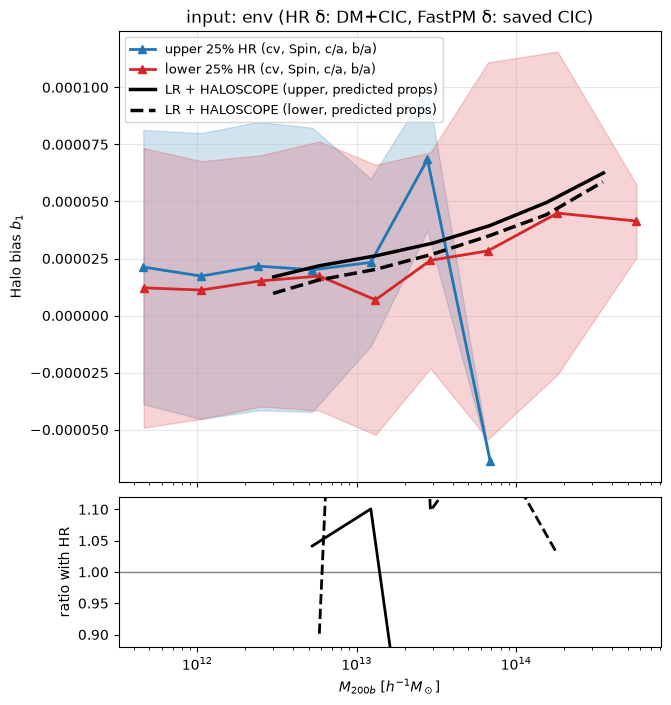

saved: output/sim_to_fastpm_haloscope/assembly_bias_env_input.pdf


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from density_field_properties.haloscope.sim_to_fastpm.assembly_bias import (
    assembly_bias_curves_for_catalog,
    attach_paranjape_bias,
    load_fastpm_matter_overdensity,
    load_sim_matter_overdensity,
    property_matrix_from_frame,
)
from density_field_properties.haloscope.sim_to_fastpm.config import (
    ASSEMBLY_BIAS_DM_BATCH_SIZE,
    DM_MASS_PARTICLE_MSUN_H,
    FASTPM_BOXSIZE_MPC_H,
    OUTPUT_FEATURES,
    SIM_BOXSIZE_MPC_H,
    default_fastpm_dm_particles_path,
)
from density_field_properties.haloscope.sim_to_fastpm.plotting import plot_assembly_bias_env_panel

ASSEMBLY_BIAS_N_GRID = 128
ASSEMBLY_LOG_MASS_BINS = np.linspace(11.5, np.log10(halos_sim["M200b"].max()), 10)

delta_sim, sim_delta_mode = load_sim_matter_overdensity(
    REPO_ROOT,
    SIM_BOXSIZE_MPC_H,
    ASSEMBLY_BIAS_N_GRID,
    DM_MASS_PARTICLE_MSUN_H,
    dm_batch_size=ASSEMBLY_BIAS_DM_BATCH_SIZE,
)
delta_fastpm, fp_delta_mode = load_fastpm_matter_overdensity(
    REPO_ROOT,
    FASTPM_BOXSIZE_MPC_H,
    ASSEMBLY_BIAS_N_GRID,
    DM_MASS_PARTICLE_MSUN_H,
    default_fastpm_dm_particles_path(),
    dm_batch_size=ASSEMBLY_BIAS_DM_BATCH_SIZE,
)
if delta_sim is None:
    sim_delta_mode = "halo CIC"
else:
    print(f"UNIT matter delta source: {sim_delta_mode}")
if delta_fastpm is None:
    fp_delta_mode = "halo CIC"
else:
    print(f"FastPM matter delta source: {fp_delta_mode}")

halos_sim["b1"] = attach_paranjape_bias(
    halos_sim,
    SIM_BOXSIZE_MPC_H,
    n_grid=ASSEMBLY_BIAS_N_GRID,
    matter_delta_field=delta_sim,
)
fp_for_bias = halos_fastpm_enriched.dropna(subset=list(OUTPUT_FEATURES)).copy()
halos_fastpm_enriched.loc[fp_for_bias.index, "b1"] = attach_paranjape_bias(
    fp_for_bias,
    FASTPM_BOXSIZE_MPC_H,
    n_grid=ASSEMBLY_BIAS_N_GRID,
    mass_column=MASS_COL_FASTPM,
    matter_delta_field=delta_fastpm,
)
fp_for_bias = halos_fastpm_enriched.dropna(subset=["b1"] + list(OUTPUT_FEATURES)).copy()

hr_props = property_matrix_from_frame(halos_sim, OUTPUT_FEATURES)
lr_props = property_matrix_from_frame(fp_for_bias, OUTPUT_FEATURES)

hr_curves = assembly_bias_curves_for_catalog(
    halos_sim["M200b"].to_numpy(),
    halos_sim["b1"].to_numpy(),
    hr_props,
    ASSEMBLY_LOG_MASS_BINS,
)
lr_curves = assembly_bias_curves_for_catalog(
    fp_for_bias[MASS_COL_FASTPM].to_numpy(),
    fp_for_bias["b1"].to_numpy(),
    lr_props,
    ASSEMBLY_LOG_MASS_BINS,
)

fig = plot_assembly_bias_env_panel(
    *hr_curves,
    lr_curves[0],
    lr_curves[1],
    lr_curves[3],
    lr_curves[4],
    title=f"input: env (HR δ: {sim_delta_mode}, FastPM δ: {fp_delta_mode})",
    output_path=str(OUTPUT_DIR / "assembly_bias_env_input.pdf"),
)
plt.show()
print("saved:", OUTPUT_DIR / "assembly_bias_env_input.pdf")


## 9. Full-run notes

- Set `MAX_SIM_HALOS` / `MAX_FASTPM_HALOS` to `None` in `haloscope/sim_to_fastpm/config.py`.
- `out_8.list` is ~1 GB; KD-tree `env` and Haloscope fits are heavy — use an interactive node or Slurm with enough RAM.
- Confirm `out_8.list` is the intended redshift snapshot; change `FASTPM_LIST_NAME` if you need another `out_*.list`.
- Dependencies: `scikit-learn`, `pyarrow` (Parquet), package `density_field_properties` on `PYTHONPATH`.